In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [3]:
base_dir="Indian Food Images"

In [4]:
class_labels = os.listdir(base_dir)
print(class_labels)

['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch', 'aloo_tikki', 'anarsa', 'ariselu', 'bandar_laddu', 'basundi', 'bhatura', 'bhindi_masala', 'biryani', 'boondi', 'butter_chicken', 'chak_hao_kheer', 'cham_cham', 'chana_masala', 'chapati', 'chhena_kheeri', 'chicken_razala', 'chicken_tikka', 'chicken_tikka_masala', 'chikki', 'daal_baati_churma', 'daal_puri', 'dal_makhani', 'dal_tadka', 'dharwad_pedha', 'doodhpak', 'double_ka_meetha', 'dum_aloo', 'gajar_ka_halwa', 'gavvalu', 'ghevar', 'gulab_jamun', 'imarti', 'jalebi', 'kachori', 'kadai_paneer', 'kadhi_pakoda', 'kajjikaya', 'kakinada_khaja', 'kalakand', 'karela_bharta', 'kofta', 'kuzhi_paniyaram', 'lassi', 'ledikeni', 'litti_chokha', 'lyangcha', 'maach_jhol', 'makki_di_roti_sarson_da_saag', 'malapua', 'misi_roti', 'misti_doi', 'modak', 'mysore_pak', 'naan', 'navrattan_korma', 'palak_paneer', 'paneer_butter_masala', 'phirni', 'pithe', 'poha', 'poornalu', 'pootharekulu', 'qubani_ka_meetha', 'rabri', 'rasgulla', 'ras_

In [5]:
data=[]
count=0

for label in class_labels:
    path = os.path.join(base_dir, label)
    print(path)
    for img in os.listdir(path):
        try:
            image=load_img(os.path.join(path, img), grayscale=False, color_mode='rgb',target_size=(128,128))
            image=img_to_array(image)
            image=image/255.0
            data.append([image,count])
        except Exception as e:
            pass
    count = count+1    

Indian Food Images\adhirasam
Indian Food Images\aloo_gobi
Indian Food Images\aloo_matar
Indian Food Images\aloo_methi
Indian Food Images\aloo_shimla_mirch
Indian Food Images\aloo_tikki
Indian Food Images\anarsa
Indian Food Images\ariselu
Indian Food Images\bandar_laddu
Indian Food Images\basundi
Indian Food Images\bhatura
Indian Food Images\bhindi_masala
Indian Food Images\biryani
Indian Food Images\boondi
Indian Food Images\butter_chicken
Indian Food Images\chak_hao_kheer
Indian Food Images\cham_cham
Indian Food Images\chana_masala
Indian Food Images\chapati
Indian Food Images\chhena_kheeri
Indian Food Images\chicken_razala
Indian Food Images\chicken_tikka
Indian Food Images\chicken_tikka_masala
Indian Food Images\chikki
Indian Food Images\daal_baati_churma
Indian Food Images\daal_puri
Indian Food Images\dal_makhani
Indian Food Images\dal_tadka
Indian Food Images\dharwad_pedha
Indian Food Images\doodhpak
Indian Food Images\double_ka_meetha
Indian Food Images\dum_aloo
Indian Food Image

In [6]:
print(len(data))

4000


In [7]:
X, y=zip(*data)

In [8]:
X[0]

array([[[0.99215686, 0.99607843, 0.9764706 ],
        [0.972549  , 0.98039216, 0.9764706 ],
        [0.98039216, 1.        , 1.        ],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.9647059 , 0.9647059 , 0.9647059 ],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99215686, 0.99607843, 0.9764706 ],
        [0.972549  , 0.98039216, 0.9764706 ],
        [0.98039216, 1.        , 1.        ],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.9647059 , 0.9647059 , 0.9647059 ],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99215686, 0.99607843, 0.9764706 ],
        [0.972549  , 0.98039216, 0.9764706 ],
        [0.98039216, 1.        , 1.        ],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.9647059 , 0.9647059 , 0.9647059 ],
        [0.99607843, 0.99607843, 0.99607843]],

       ...,

       [[0.972549  , 0.99607843, 0.99607843],
        [0.99607843, 0.9647059 , 0.95686275],
        [1.        , 0

In [9]:
X=np.array(X)
y=np.array(y)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3200, 128, 128, 3) (800, 128, 128, 3) (3200,) (800,)


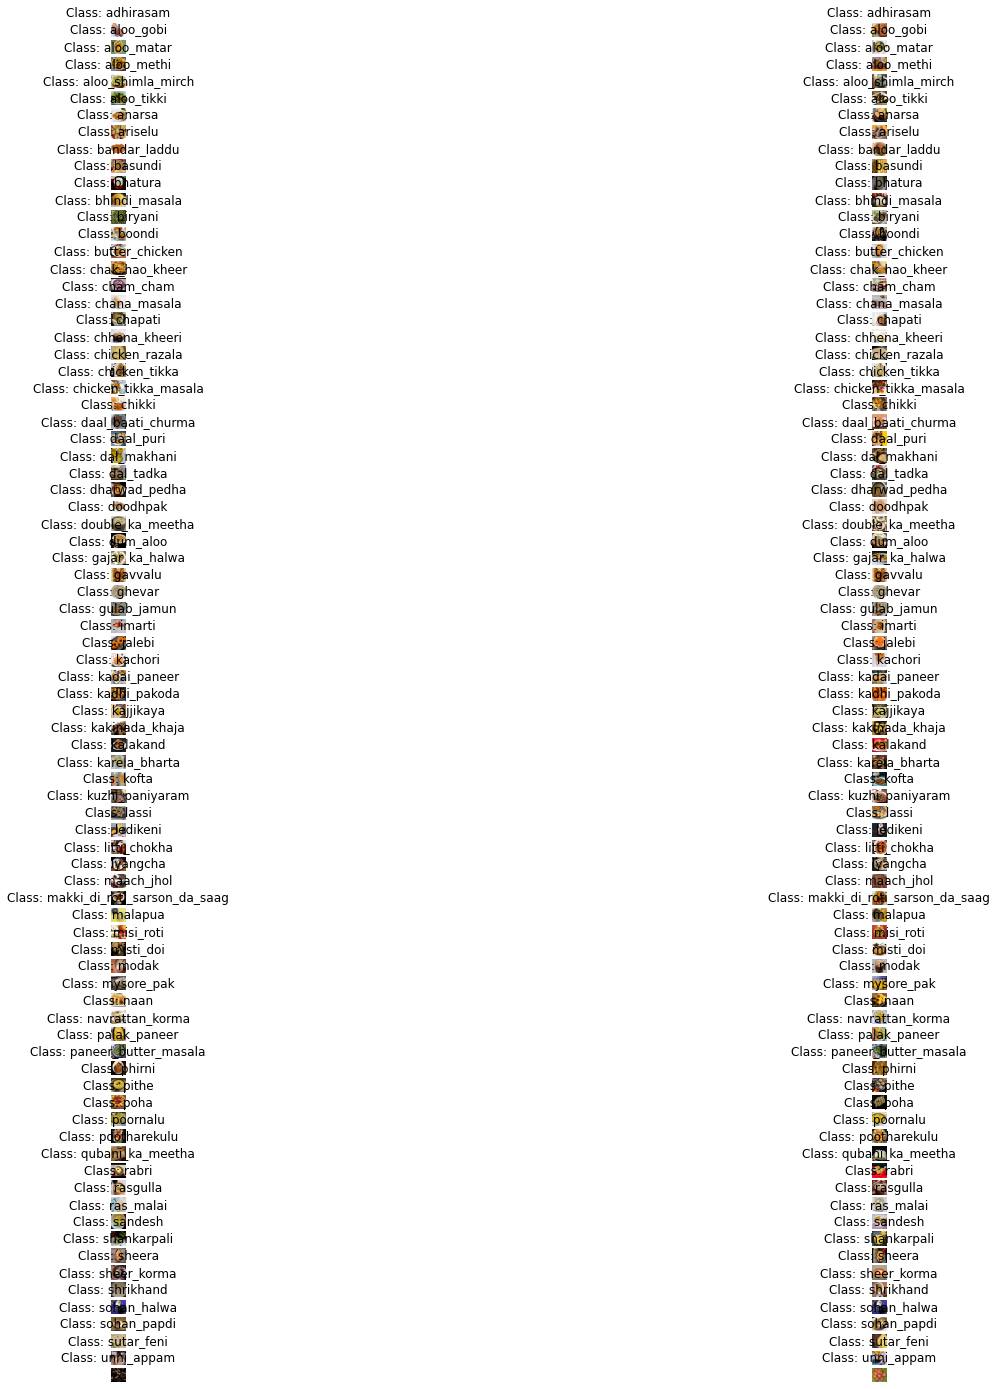

In [11]:
from random import randint
def show_images(X, y, class_labels, num_images=16, images_per_class=2):
    num_classes = len(class_labels)
    plt.figure(figsize=(25, 25))
    for i in range(num_classes):
        class_idx = i
        for j in range(images_per_class):
            ax = plt.subplot(num_classes, images_per_class, i * images_per_class + j + 1)
            idx = randint(0, 49)  # Select a random image index for the current class
            plt.imshow(X[class_idx * 50 + idx])  # Indexing to get the appropriate image
            plt.axis("off")
            plt.title("Class: {}".format(class_labels[class_idx]))
    plt.show()
show_images(X, y, class_labels)    

In [12]:
y = to_categorical(y)
y_train= to_categorical(y_train)
y_test= to_categorical(y_test)

In [13]:
import tensorflow as tf
vgg_model= tf.keras.applications.VGG19(include_top=False,
                                     weights="imagenet",
                                     input_tensor= None,
                                     input_shape=(128,128,3),
                                     pooling="max",
                                     classes = 1000)
vgg_model.trainable=False

In [14]:
inputs = vgg_model.input
m=tf.keras.layers.Dense(512,activation='relu')(vgg_model.output)
m=tf.keras.layers.Dropout(rate=0.5)(m)
outputs=tf.keras.layers.Dense(80, activation='softmax')(m)
vgg_model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [15]:
vgg_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
vgg_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0    

In [16]:
history = vgg_model.fit(x=X, y=y, batch_size=32, epochs=50, validation_data=(X_train, y_train), shuffle=True)

Epoch 1/50


125/125 [==============================] - 439s 4s/step - loss: 4.4130 - accuracy: 0.0253 - val_loss: 4.1050 - val_accuracy: 0.0875
Epoch 2/50
125/125 [==============================] - 461s 4s/step - loss: 4.0273 - accuracy: 0.0655 - val_loss: 3.6734 - val_accuracy: 0.1397
Epoch 3/50
125/125 [==============================] - 637s 5s/step - loss: 3.7240 - accuracy: 0.1067 - val_loss: 3.3726 - val_accuracy: 0.2031
Epoch 4/50
125/125 [==============================] - 441s 4s/step - loss: 3.5178 - accuracy: 0.1305 - val_loss: 3.1387 - val_accuracy: 0.2650
Epoch 5/50
125/125 [==============================] - 488s 4s/step - loss: 3.3604 - accuracy: 0.1610 - val_loss: 2.9910 - val_accuracy: 0.2816
Epoch 6/50
125/125 [==============================] - 434s 3s/step - loss: 3.1862 - accuracy: 0.1880 - val_loss: 2.8115 - val_accuracy: 0.3288
Epoch 7/50
125/125 [==============================] - 427s 3s/step - loss: 3.0942 - accuracy: 0.2095 - val_loss: 2.7257 - val_accuracy: 0.37

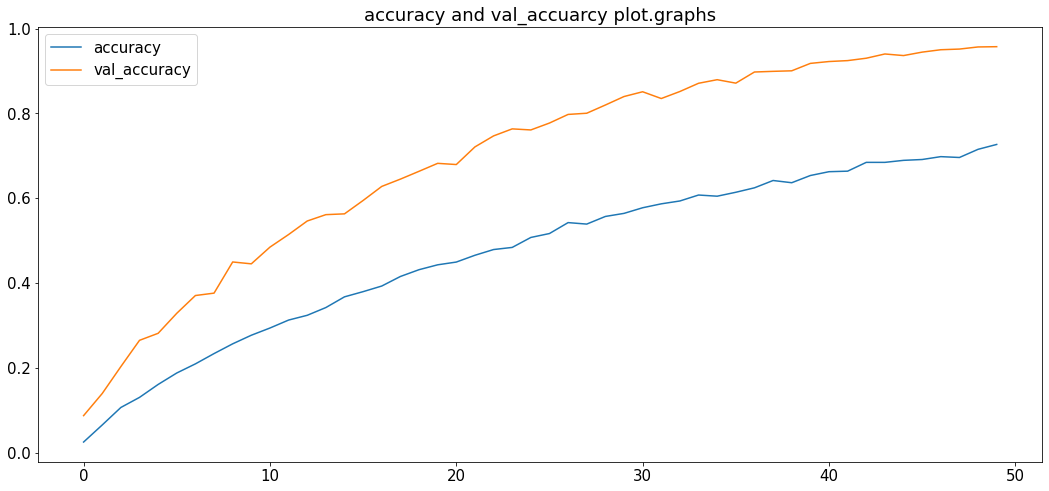

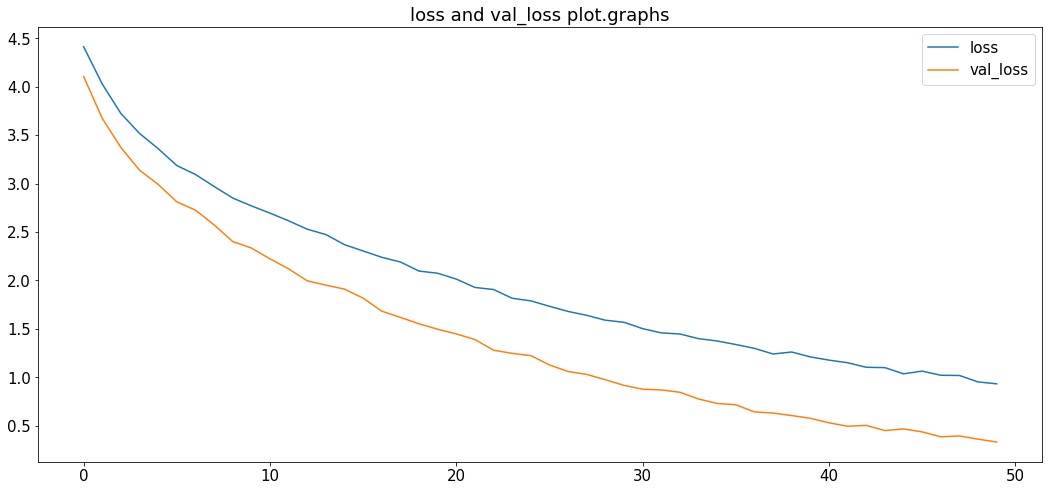

In [17]:
plt.figure(figsize=(18,8))
plt.rcParams["font.size"]=15
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title(label="accuracy and val_accuarcy plot.graphs")
plt.legend()
plt.show()

plt.figure(figsize=(18,8))
plt.rcParams["font.size"]=15
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title(label="loss and val_loss plot.graphs")
plt.legend()
plt.show()

In [18]:
prediction = vgg_model.predict(X_test,batch_size =32, verbose=1)

25/25 [==============================] - 57s 2s/step


In [19]:
print(prediction)

[[1.95551024e-07 1.04730287e-04 8.27336116e-05 ... 3.33539134e-08
  1.71489719e-05 5.24098320e-09]
 [9.37487523e-04 8.10605125e-05 1.75128880e-05 ... 1.15654024e-03
  1.16082694e-04 2.28260085e-03]
 [2.54599901e-04 4.97459223e-05 2.27025565e-04 ... 7.25475775e-06
  6.61196478e-04 3.14788508e-06]
 ...
 [2.06120589e-04 9.19463128e-05 7.88723639e-07 ... 1.85706187e-04
  9.88689005e-01 2.05651403e-07]
 [1.25016970e-06 1.87394524e-03 1.80383921e-02 ... 6.64676989e-08
  1.52823905e-05 7.73308057e-05]
 [5.03218826e-06 1.79785956e-03 3.81052669e-04 ... 7.32930516e-07
  2.34475265e-05 5.99985560e-06]]


In [20]:
labels=[]
for i in range(len(prediction)):
    labels.append(np.argmax(prediction[i]))

In [24]:
print(labels)

[11, 16, 10, 78, 59, 1, 35, 4, 44, 16, 68, 76, 64, 29, 77, 69, 23, 9, 3, 6, 28, 33, 71, 70, 50, 4, 77, 64, 42, 25, 45, 24, 78, 24, 47, 2, 17, 39, 49, 77, 44, 26, 60, 14, 62, 71, 39, 3, 2, 61, 40, 79, 6, 36, 11, 17, 44, 28, 64, 78, 64, 18, 51, 67, 45, 30, 75, 12, 4, 0, 53, 64, 66, 36, 17, 62, 71, 28, 7, 31, 57, 10, 29, 16, 62, 15, 70, 36, 46, 52, 28, 47, 66, 15, 39, 22, 26, 35, 31, 0, 16, 50, 14, 3, 57, 8, 0, 3, 60, 64, 66, 61, 74, 32, 49, 70, 14, 23, 13, 66, 34, 48, 73, 57, 70, 51, 70, 77, 14, 27, 59, 78, 40, 52, 32, 48, 61, 60, 11, 34, 47, 28, 22, 12, 8, 9, 49, 20, 42, 28, 37, 49, 5, 46, 64, 63, 20, 69, 55, 47, 75, 23, 47, 46, 0, 73, 24, 42, 32, 22, 42, 9, 70, 9, 58, 53, 51, 6, 49, 65, 65, 16, 71, 65, 66, 70, 67, 44, 13, 21, 42, 63, 77, 30, 69, 23, 74, 43, 24, 1, 48, 70, 26, 74, 57, 35, 0, 67, 72, 34, 21, 79, 53, 47, 25, 6, 58, 55, 11, 77, 17, 50, 42, 27, 38, 55, 33, 30, 44, 12, 31, 64, 38, 40, 8, 61, 24, 67, 6, 23, 24, 16, 54, 79, 72, 9, 62, 2, 51, 2, 29, 10, 30, 70, 40, 68, 73, 32, 

In [21]:
true_labels=[]
for i in range(len(y_test)):
    true_labels.append(np.argmax(y_test[i]))

In [22]:
print(true_labels)

[11, 69, 10, 78, 59, 1, 35, 4, 3, 16, 68, 76, 22, 29, 77, 69, 23, 9, 11, 6, 28, 33, 71, 34, 50, 4, 77, 64, 42, 25, 45, 24, 78, 49, 47, 2, 17, 39, 49, 77, 44, 20, 60, 14, 62, 71, 39, 3, 2, 61, 21, 79, 6, 36, 11, 17, 44, 28, 64, 78, 64, 18, 51, 67, 45, 30, 75, 12, 39, 0, 25, 64, 66, 0, 17, 62, 71, 28, 7, 31, 57, 10, 29, 16, 68, 15, 70, 36, 46, 52, 28, 47, 66, 15, 39, 22, 26, 73, 31, 0, 9, 50, 45, 3, 57, 8, 0, 3, 60, 64, 66, 39, 74, 32, 24, 70, 14, 23, 13, 66, 34, 48, 31, 57, 70, 51, 34, 77, 14, 27, 59, 78, 40, 52, 32, 48, 61, 60, 11, 34, 47, 28, 22, 12, 8, 9, 49, 20, 42, 69, 37, 49, 5, 46, 61, 63, 20, 69, 55, 47, 69, 76, 47, 46, 0, 73, 24, 42, 4, 22, 25, 9, 70, 9, 58, 31, 51, 6, 49, 65, 49, 29, 71, 25, 66, 70, 67, 44, 13, 21, 42, 63, 77, 33, 26, 23, 74, 43, 5, 1, 48, 70, 31, 74, 57, 35, 0, 67, 72, 34, 21, 79, 53, 47, 25, 6, 58, 55, 11, 77, 17, 50, 42, 27, 38, 55, 72, 30, 44, 21, 31, 64, 38, 40, 8, 1, 24, 28, 6, 23, 24, 63, 54, 79, 72, 15, 62, 3, 51, 2, 29, 10, 30, 70, 40, 68, 56, 32, 75,

In [23]:
model_accuracy = accuracy_score(y_true = true_labels, y_pred = labels)
print("VGG19 model Accuracy is {:.2f}%".format(model_accuracy*100.0))

VGG19 model Accuracy is 95.88%


In [24]:
print(classification_report(y_true=true_labels, y_pred=labels, target_names=class_labels))

                              precision    recall  f1-score   support

                   adhirasam       1.00      1.00      1.00        13
                   aloo_gobi       0.82      0.93      0.87        15
                  aloo_matar       1.00      1.00      1.00         8
                  aloo_methi       1.00      0.87      0.93        15
           aloo_shimla_mirch       1.00      0.92      0.96        12
                  aloo_tikki       1.00      1.00      1.00        15
                      anarsa       0.93      1.00      0.96        13
                     ariselu       1.00      1.00      1.00         7
                bandar_laddu       1.00      1.00      1.00        13
                     basundi       0.92      0.92      0.92        12
                     bhatura       1.00      1.00      1.00         6
               bhindi_masala       1.00      0.83      0.91        12
                     biryani       1.00      1.00      1.00         3
                   

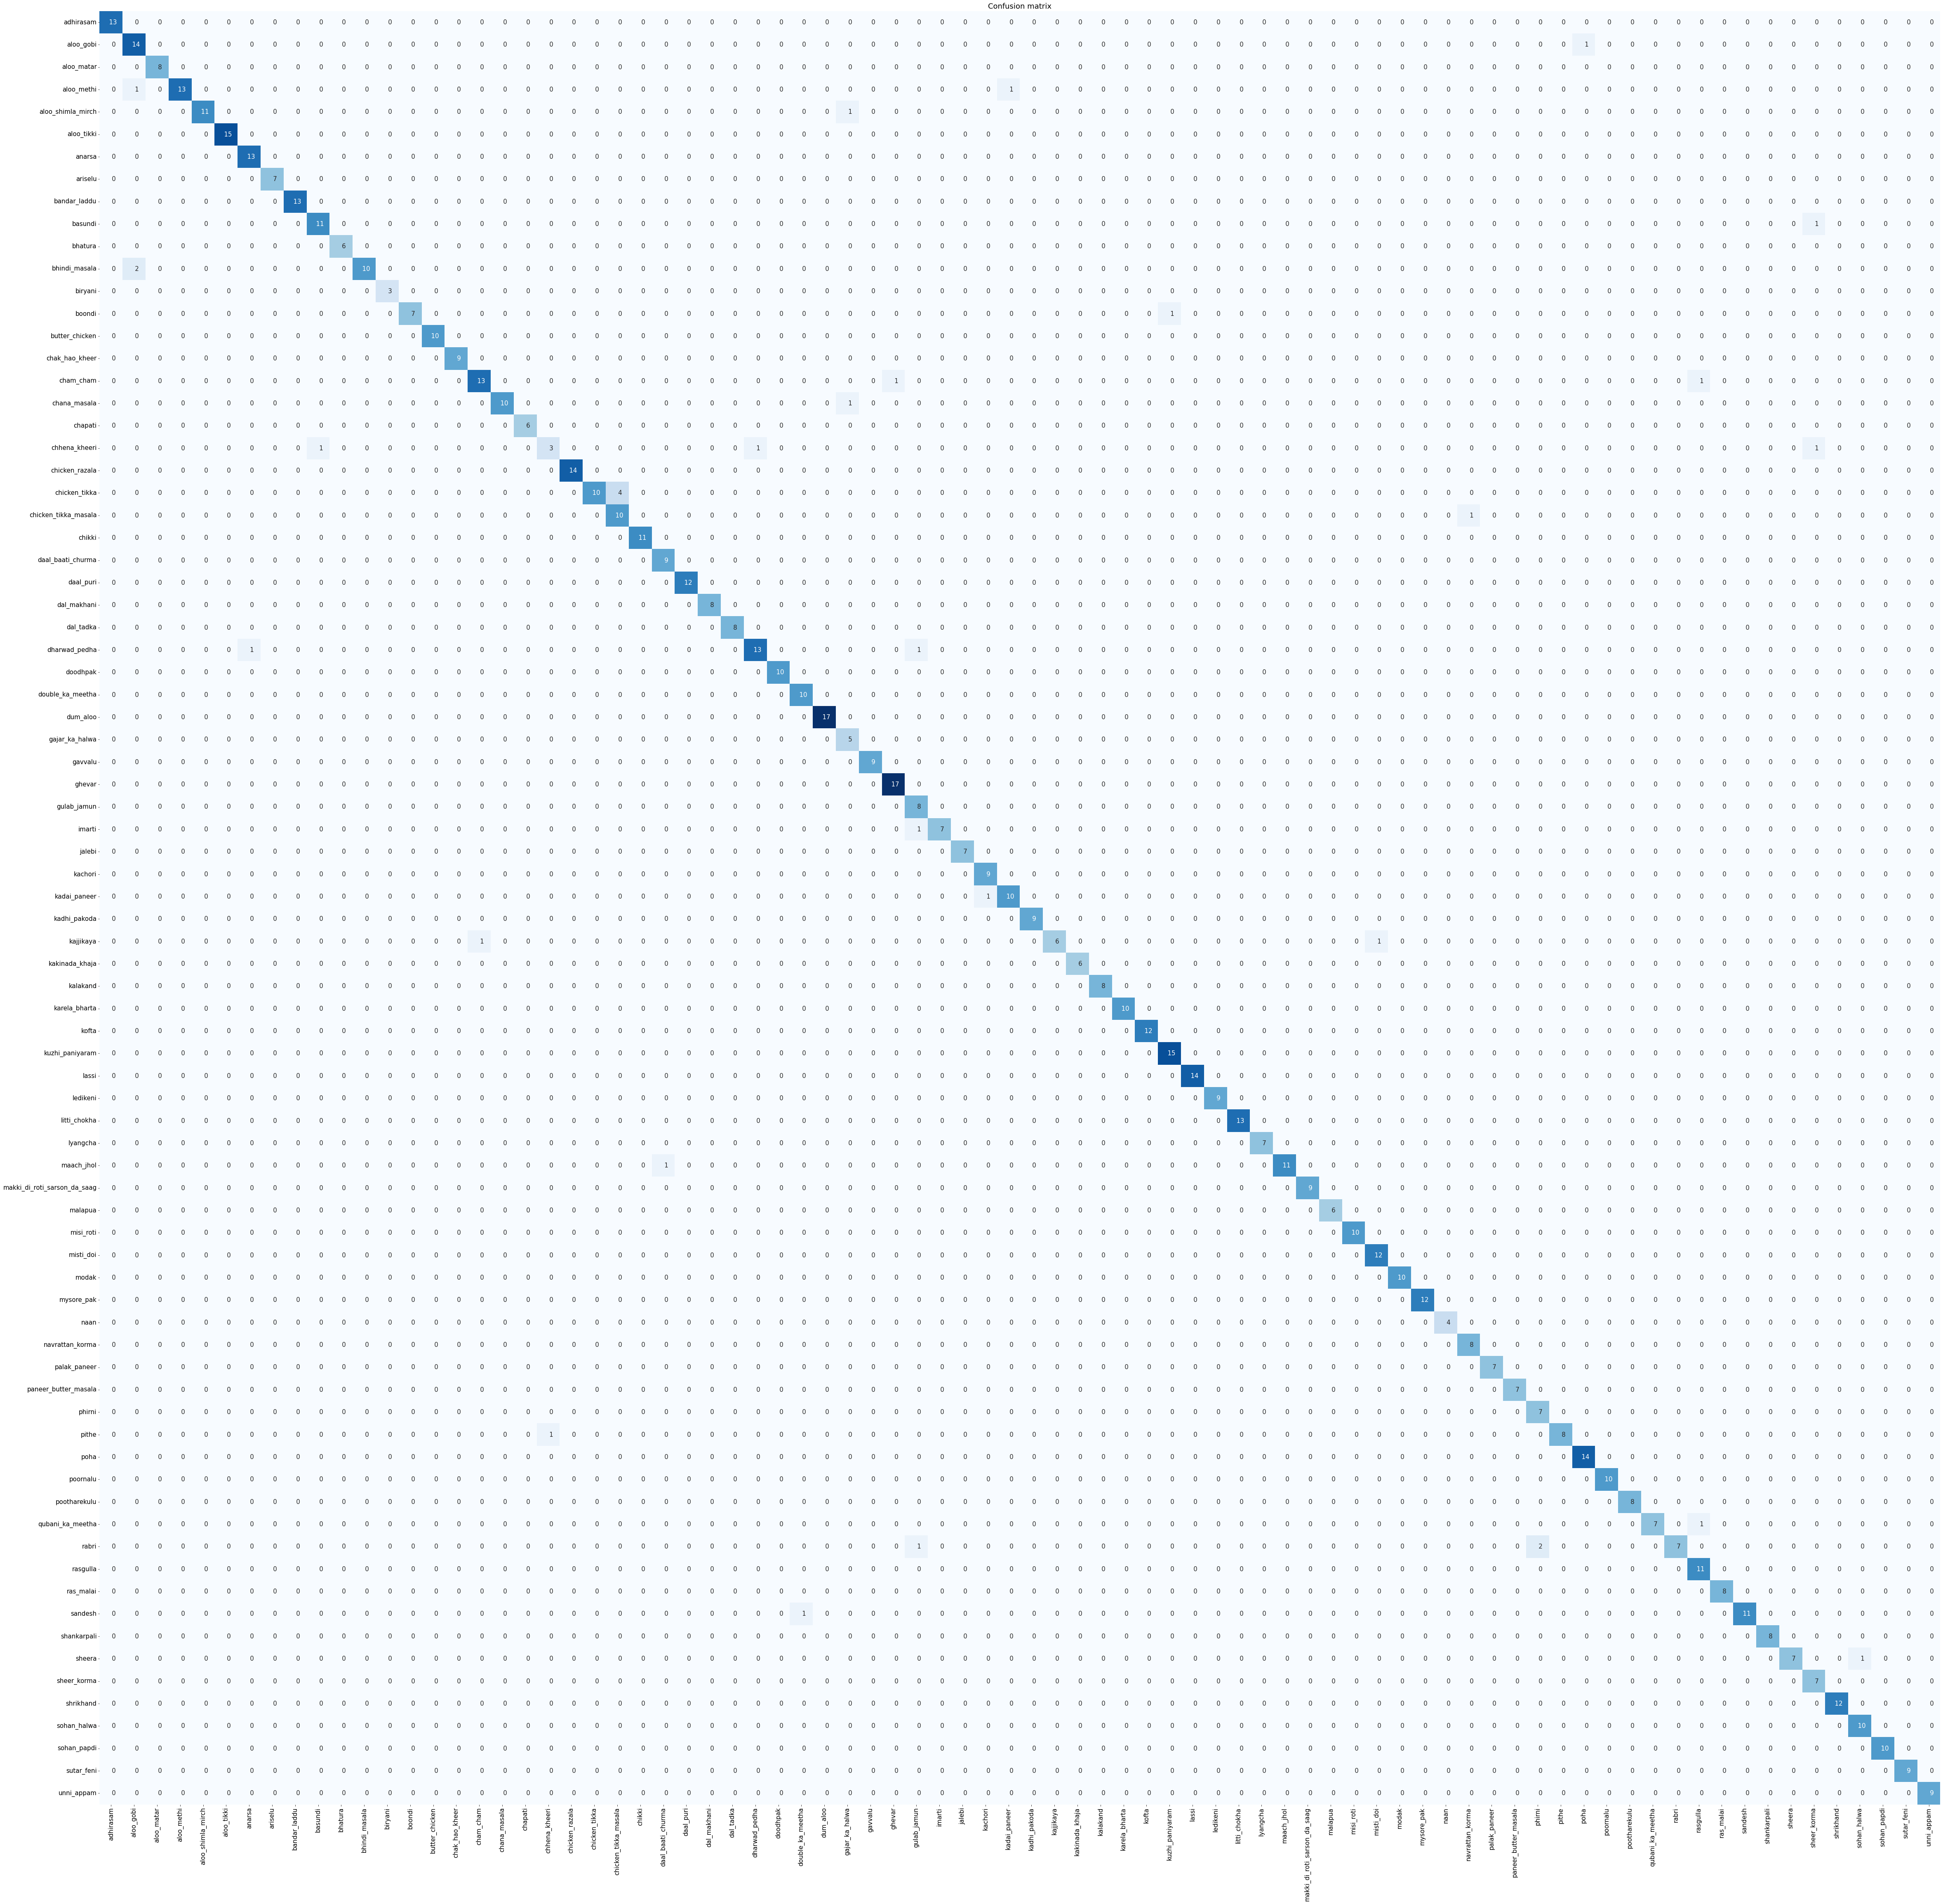

In [25]:
plt.figure(figsize=(80,80))
sns.heatmap(data=confusion_matrix(y_true=true_labels, y_pred=labels),
           annot=True,
           fmt='4d',
           cbar=False,
           cmap=plt.cm.Blues,
           xticklabels=class_labels,
           yticklabels=class_labels)
plt.title(label='Confusion matrix')
plt.show()

In [26]:
vgg_model.save(filepath="VGG16_model95.h5")